In [1]:
import torch
import numpy as np
import os
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors

from scipy.stats import pearsonr, spearmanr
from torchmetrics.image import StructuralSimilarityIndexMeasure
from scipy.stats import exponweib
import seaborn as sns
from scipy.optimize import curve_fit


In [2]:
preds_dir = '../../preds/'
dataset_dir = '../../data/all_years_merged_era5.nc'

SCALING_FACTOR = 4
TEST_YEAR = 2014
TRAIN_START_1 = '1980-01-01'
TRAIN_END_1 = '1982-12-31'
TRAIN_START_2 = '2010-01-01'
TRAIN_END_2 = '2012-12-31'
years = list(range(2014, 2024))
print(years)
rand_4x_years = [[1996, 2013, 1997], [1981, 2006, 1985], [1989, 1983, 2004], [2012, 1989, 1999], [1980, 1994, 1993]]
rand_8x_years = [[1981, 1987, 1983], [1990, 2010, 1983], [2004, 1992, 1982], [2013, 2002, 1996], [2010, 1996, 1992]]

random_train_years = rand_4x_years if SCALING_FACTOR == 4 else rand_8x_years



[2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [21]:
def load_dataset(data, start, end, patch_size):
    dataset = xr.open_dataset(data).sel(valid_time=slice(start, end)).isel(
        longitude=slice(0, patch_size), latitude=slice(0, patch_size))
    return dataset
def load_random_dataset(data, random_years, patch_size):
    dataset = xr.open_dataset(data).isel(
        longitude=slice(0, patch_size), latitude=slice(0, patch_size))
    dataset = dataset.sel(valid_time=dataset['valid_time'].dt.year.isin(random_years))
    data_list = []
    for year in random_years:
        data_list.append(dataset.sel(valid_time = dataset['valid_time'].dt.year == year))
    dataset = xr.concat(data_list, dim='valid_time') 
    return dataset  
def normalize_data(data, custom_scale = None):
    returned_scale = {}
    for var in data:
        
        if custom_scale and var in custom_scale:
            min_val = custom_scale[var]['min']
            max_val = custom_scale[var]['max']
        else:
            min_val = data[var].values.min()
            max_val = data[var].values.max()
            
            returned_scale[var] = {'min': min_val, 'max': max_val}
            
            
        data[var] = (data[var] - min_val) / (max_val - min_val)
        
        
    return data, returned_scale


def average_pooling(data, scale, to_int=False):
    new_h, new_w = data.shape[0] // scale, data.shape[1] // scale
    data = data.reshape(new_h, scale, new_w, scale).mean(axis=(1, 3))
    if to_int:
        data = np.uint8(data)
    return data

def get_original_wind_speed(data, scale):
    u_min = scale['u10']['min'].item()
    u_max = scale['u10']['max'].item()
    v_min = scale['v10']['min'].item()
    v_max = scale['v10']['max'].item()
    
    norm_u = data[:,0,:,:]
    norm_v = data[:,1,:,:]
    
    u = norm_u * (u_max - u_min) + u_min
    v = norm_v * (v_max - v_min) + v_min


    return torch.sqrt(u**2 + v**2)


def mse(pred, target):
    return ((pred - target) ** 2).mean()
def mae(pred, target):
    return (np.abs(pred - target)).mean()


def get_metrics(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.numpy()
    mse_val = mse(preds, target)
    mae_val = mae(preds, target)
    return mse_val, mae_val


def get_skill_score(model_score, baseline_score):
    return 1 - (model_score / baseline_score)


def get_descriptive_stats(data):
    return data.mean(), data.std(), data.min(), data.max()


def get_SSIM(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.clone().detach().unsqueeze(0).unsqueeze(0)
        target = target.clone().detach().unsqueeze(0).unsqueeze(0)
    else:
        preds = torch.tensor(preds).unsqueeze(0).unsqueeze(0)
        target = torch.tensor(target).unsqueeze(0).unsqueeze(0)
    ssim = StructuralSimilarityIndexMeasure()
    return ssim(preds, target)

def get_correlation(preds, target, method='pearson'):
    preds = preds.flatten()
    target = target.flatten()
    if method == 'spearman':
        return spearmanr(preds, target)
    else:
        return pearsonr(preds, target)



In [22]:
import datetime

def get_ground_truth_ws(data_dir, train_start,train_end, test_year):
    
    start = min(int(train_start.split('-')[0]), test_year)
    end = max(int(train_end.split('-')[0]), test_year)
    dataset = load_dataset(data_dir, start=f'{start}-01-01', end=f'{end}-12-31', patch_size=32)
    train_split = dataset.sel(valid_time=slice(train_start, train_end))
    test_split = dataset.sel(valid_time=slice(f'{test_year}-01-01', f'{test_year}-12-31'))
    _, scale = normalize_data(train_split)
    gt_ws = np.sqrt(test_split['u10'].values**2 + test_split['v10'].values**2)
    return test_split, gt_ws, scale

eval_split, ground_truth_wind_speeds, scale1 = get_ground_truth_ws(data_dir=dataset_dir,
                                                                    train_start=TRAIN_START_1,
                                                                    train_end=TRAIN_END_1,
                                                                    test_year=TEST_YEAR)
_, _, scale2 = get_ground_truth_ws(data_dir=dataset_dir,
                                      train_start=TRAIN_START_2,
                                      train_end=TRAIN_END_2,
                                      test_year=TEST_YEAR)

def get_ground_truth_2(data_dir, train_start,random_years, test_year):
    dataset = load_dataset(data_dir, start=train_start, end=f'{test_year}-12-31', patch_size=32)
    train_split = load_random_dataset(data_dir, random_years, patch_size=32)
    test_split = dataset.sel(valid_time=slice(f'{test_year}-01-01', f'{test_year}-12-31'))
    _, scale = normalize_data(train_split)
    gt_ws = np.sqrt(test_split['u10'].values**2 + test_split['v10'].values**2)
    return test_split, gt_ws, scale


def get_low_res_ws(test_data, scaling_factor):
    u10, v10 = [], []
    for i in range(test_data['u10'].shape[0]):
        u10.append(average_pooling(test_data['u10'][i].values, scaling_factor, False))
        v10.append(average_pooling(test_data['v10'][i].values, scaling_factor, False))
    u10 = np.array(u10)
    v10 = np.array(v10)
    lr_ws = np.sqrt(u10**2 + v10**2)
    return lr_ws

lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)

def get_wind_speed_fields(files_dir, scaling_factor, year, normalization_scales, rand_scales, lr_ws, gt_ws):
    files = os.listdir(files_dir)
    ws_fields = [lr_ws, gt_ws]
    names = ["LR Input", "HR Ground Truth"]
    scale_1 = normalization_scales[0]
    scale_2 = normalization_scales[1]
   
    for file in files:
        if not file.endswith(f'{scaling_factor}x.pt'):
            continue
            
        if 'baseline' in file:
            continue      
        if file == f'EDSR_2010_13_{year}_{scaling_factor}x.pt':
            field = torch.load(files_dir + file, weights_only=False)

            edsr_1013 = get_original_wind_speed(field, scale_2)
            names.append("EDSR 2010 - 2013")
            ws_fields.append(edsr_1013)
            
        elif file == f'EDSR_ws_temp_{year}_{scaling_factor}x.pt':
            field = torch.load(files_dir + file, weights_only=False)            

            names.append("EDSR 1980 - 1983")
            edsr = get_original_wind_speed(field, scale_1)
            ws_fields.append(edsr)
        
        elif "random" in file:
            field = torch.load(files_dir + file, weights_only=False)
            if file == f'EDSR_random_{year}_{scaling_factor}x.pt':
                names.append("EDSR Random")
                edsr_rand = get_original_wind_speed(field, rand_scales[0])
                ws_fields.append(edsr_rand)
            else:
                for i in range(1,5):
                    if file == f'EDSR_random_{i}_{year}_{scaling_factor}x.pt':
                        names.append(f"EDSR Random {i}")
                        edsr_rand = get_original_wind_speed(field, rand_scales[i])
                        ws_fields.append(edsr_rand)
                    
    return ws_fields, names



In [5]:
random_scales = [scale for _,_,scale in [get_ground_truth_2(dataset_dir, TRAIN_START_1, random_train_years[i], TEST_YEAR) for i in range(5)]]
print(random_scales[0])

{'u10': {'min': np.float32(-16.697983), 'max': np.float32(22.682812)}, 'v10': {'min': np.float32(-16.495743), 'max': np.float32(20.650955)}, 'd2m': {'min': np.float32(243.72585), 'max': np.float32(295.67603)}, 't2m': {'min': np.float32(246.60359), 'max': np.float32(308.2798)}, 'msl': {'min': np.float32(96950.625), 'max': np.float32(104461.34)}, 'tp': {'min': np.float32(0.0), 'max': np.float32(0.013988018)}}


In [6]:
ws_fields, names = get_wind_speed_fields(files_dir=preds_dir, 
                                        scaling_factor=SCALING_FACTOR, 
                                        year=TEST_YEAR, 
                                        normalization_scales=[scale1, scale2], 
                                        rand_scales=random_scales,
                                        lr_ws=lr_wind_speeds, 
                                        gt_ws=ground_truth_wind_speeds)
print(names)

['LR Input', 'HR Ground Truth', 'EDSR 2010 - 2013', 'EDSR 1980 - 1983', 'EDSR Random 3', 'EDSR Random 2', 'EDSR Random 4', 'EDSR Random 1', 'EDSR Random']


945


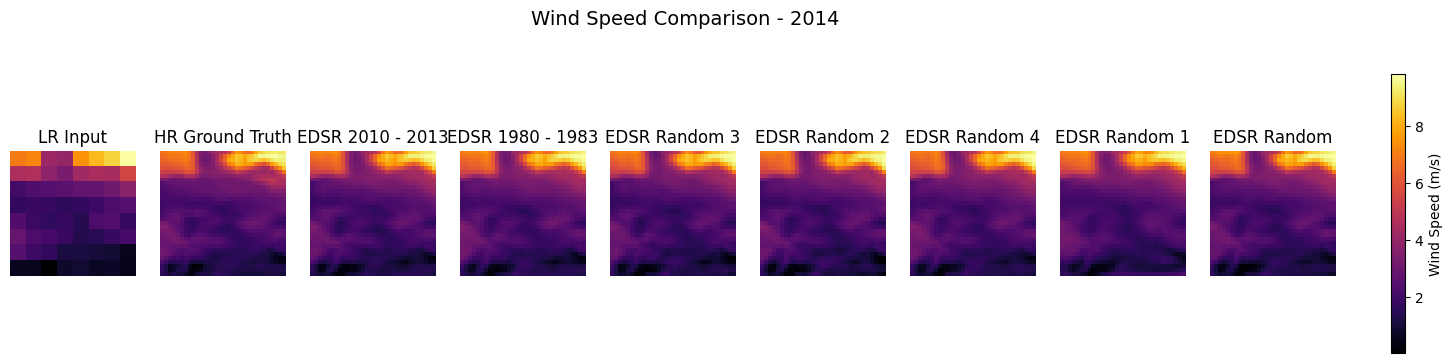

In [7]:
longitudes = eval_split.longitude.values[:32]
latitudes = eval_split.latitude.values[:32]

def plot_comparison(fields, names, index):
    assert len(fields) == len(names)
    fig, ax = plt.subplots(1, len(names), figsize=(18, 8))
    fields = [field[index] for field in fields]
    long_ticks = np.linspace(longitudes[0], longitudes[-1], 5)
    lat_ticks = np.linspace(latitudes[0], latitudes[-1], 5)
    for i, field in enumerate(fields):
        if names[i] == "HR Ground Truth":
            im = ax[i].imshow(field, cmap='inferno')
        else:
            ax[i].imshow(field, cmap='inferno')
        ax[i].set_title(names[i])
        ax[i].set_title(names[i])
        # turn off the axis labels
        ax[i].axis('off')
        
        #ax[i].set_xticks(np.linspace(0, field.shape[1]-1, len(long_ticks)))
        #ax[i].set_yticks(np.linspace(0, field.shape[0]-1, len(lat_ticks)))
        #ax[i].set_xticklabels([f'{round(i, 1)}' for i in long_ticks])
        #ax[i].set_yticklabels([f'{round(i, 1)}' for i in lat_ticks])
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.01, pad=0.04)
    cbar.set_label('Wind Speed (m/s)')
    plt.suptitle(f"Wind Speed Comparison - {TEST_YEAR}", fontsize=14, y=.75)
    plt.show()


index = np.random.randint(0, len(ground_truth_wind_speeds))
print(index)
plot_comparison(ws_fields, names, index)

In [8]:

ws_dict = {year: {} for year in years}
for year in years:
        eval_split, ground_truth_wind_speeds, scale1 = get_ground_truth_ws(data_dir=dataset_dir,
                                                                        train_start=TRAIN_START_1,
                                                                        train_end=TRAIN_END_1,
                                                                        test_year=year)
        _, _, scale2 = get_ground_truth_ws(data_dir=dataset_dir,
                                            train_start=TRAIN_START_2,
                                            train_end=TRAIN_END_2,
                                            
                                            test_year=year)
        
        random_scales = [scale for _,_,scale in [get_ground_truth_2(dataset_dir, TRAIN_START_1, random_train_years[i], year) for i in range(5)]]

        
        lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)
        ws_fields, names = get_wind_speed_fields(files_dir=preds_dir, 
                                                scaling_factor=SCALING_FACTOR, 
                                                year=year, 
                                                normalization_scales=[scale1, scale2],
                                                rand_scales=random_scales,
                                                lr_ws=lr_wind_speeds, 
                                                gt_ws=ground_truth_wind_speeds)
        
        edsr_80 = ws_fields[names.index('EDSR 1980 - 1983')]
        edsr_10 = ws_fields[names.index('EDSR 2010 - 2013')]
        edsr_rand = ws_fields[names.index('EDSR Random')]
        ws_dict[year]['EDSR_80'] = edsr_80
        ws_dict[year]['EDSR_10'] = edsr_10
        ws_dict[year]['EDSR_Random'] = edsr_rand
        ws_dict[year]['Ground Truth'] = ground_truth_wind_speeds
        for i in range(1,5):
            ws_dict[year][f'EDSR_Random_{i}'] = ws_fields[names.index(f'EDSR Random {i}')]


In [9]:
def get_metrics_over_time(years):
    mses = {'EDSR_80': [], 'EDSR_10': [], 'EDSR_Random': [], 'EDSR_Random_1': [], 'EDSR_Random_2': [], 'EDSR_Random_3': [], 'EDSR_Random_4': []}
    maes = {'EDSR_80': [], 'EDSR_10': [], 'EDSR_Random': [], 'EDSR_Random_1': [], 'EDSR_Random_2': [], 'EDSR_Random_3': [], 'EDSR_Random_4': []}
  
    mse_skill_scores = {'80_10': [], '80_Random': [], '80_Random_1': [], '80_Random_2': [], '80_Random_3': [], '80_Random_4': []}
    mae_skill_scores = {'80_10': [], '80_Random': [], '80_Random_1': [], '80_Random_2': [], '80_Random_3': [], '80_Random_4': []}
    
    for year in years:
        ground_truth_wind_speeds = ws_dict[year]['Ground Truth']
        
        
        mse_edsr80, mae_edsr80 = get_metrics(ws_dict[year]['EDSR_80'], ground_truth_wind_speeds)
        mse_edsr10, mae_edsr10 = get_metrics(ws_dict[year]['EDSR_10'], ground_truth_wind_speeds)
        mse_rand, mae_rand = get_metrics(ws_dict[year]['EDSR_Random'], ground_truth_wind_speeds)
        mse_skill_scores['80_10'].append(get_skill_score(mse_edsr10, mse_edsr80))
        mse_skill_scores['80_Random'].append(get_skill_score(mse_rand, mse_edsr80))
        mae_skill_scores['80_10'].append(get_skill_score(mae_edsr10, mae_edsr80))
        mae_skill_scores['80_Random'].append(get_skill_score(mae_rand, mae_edsr80))
        
        mses['EDSR_80'].append(mse_edsr80)
        mses['EDSR_10'].append(mse_edsr10)
        maes['EDSR_80'].append(mae_edsr80)
        maes['EDSR_10'].append(mae_edsr10)
        mses['EDSR_Random'].append(mse_rand)
        maes['EDSR_Random'].append(mae_rand)
        
        for i in range(1,5):
            mse_rand_i, mae_rand_i = get_metrics(ws_dict[year][f'EDSR_Random_{i}'], ground_truth_wind_speeds)
            mse_skill_scores[f'80_Random_{i}'].append(get_skill_score(mse_rand_i, mse_edsr80))
            mae_skill_scores[f'80_Random_{i}'].append(get_skill_score(mae_rand_i, mae_edsr80))
            mses[f'EDSR_Random_{i}'].append(mse_rand_i)
            maes[f'EDSR_Random_{i}'].append(mae_rand_i)
        
    return mses, maes, mse_skill_scores, mae_skill_scores


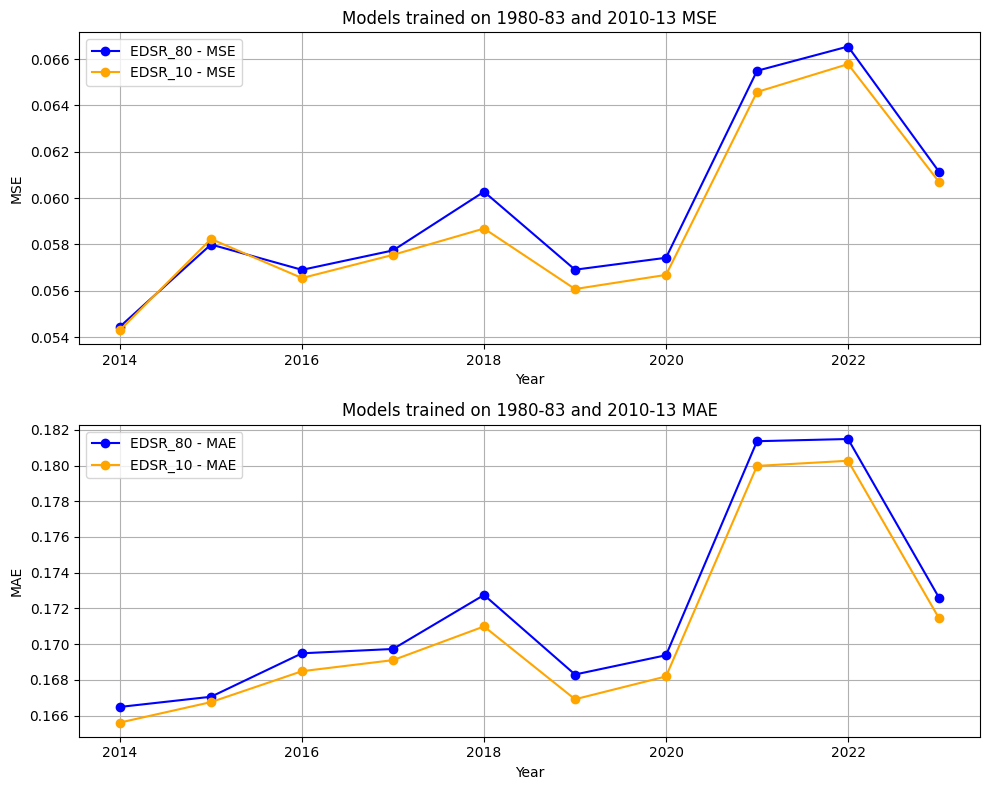

In [10]:
def plot_metrics_over_time(years, mses, maes):
    n_models = len(mses)
    fig, ax = plt.subplots(2, 1, figsize=(10, 8))
    colors = ['blue', 'orange']
    for i, model in enumerate(['EDSR_80', 'EDSR_10']):
        # Plot MSE for the current model
        ax[0].plot(years, mses[model], 'o-', label=f"{model} - MSE", color=colors[i])
        ax[0].set_title(f'Models trained on 1980-83 and 2010-13 MSE')
        ax[0].set_xlabel('Year')
        ax[0].set_ylabel('MSE')
        ax[0].legend()
        ax[0].grid(True)

        # Plot MAE for the current model
        ax[1].plot(years, maes[model], 'o-', label=f"{model} - MAE", color=colors[i])
        ax[1].set_title(f'Models trained on 1980-83 and 2010-13 MAE')
        ax[1].set_xlabel('Year')
        ax[1].set_ylabel('MAE')
        ax[1].legend()
        ax[1].grid(True)

    plt.tight_layout()
    plt.show()

mses, maes, mse_skill_scores, mae_skill_scores = get_metrics_over_time(years)
plot_metrics_over_time(years, mses, maes)

In [11]:

# label based on the random years used for training
rand_labels = [str(years) for years in random_train_years]
rand_labels.insert(0, '1980-1982')
print(rand_labels)

['1980-1982', '[1996, 2013, 1997]', '[1981, 2006, 1985]', '[1989, 1983, 2004]', '[2012, 1989, 1999]', '[1980, 1994, 1993]']


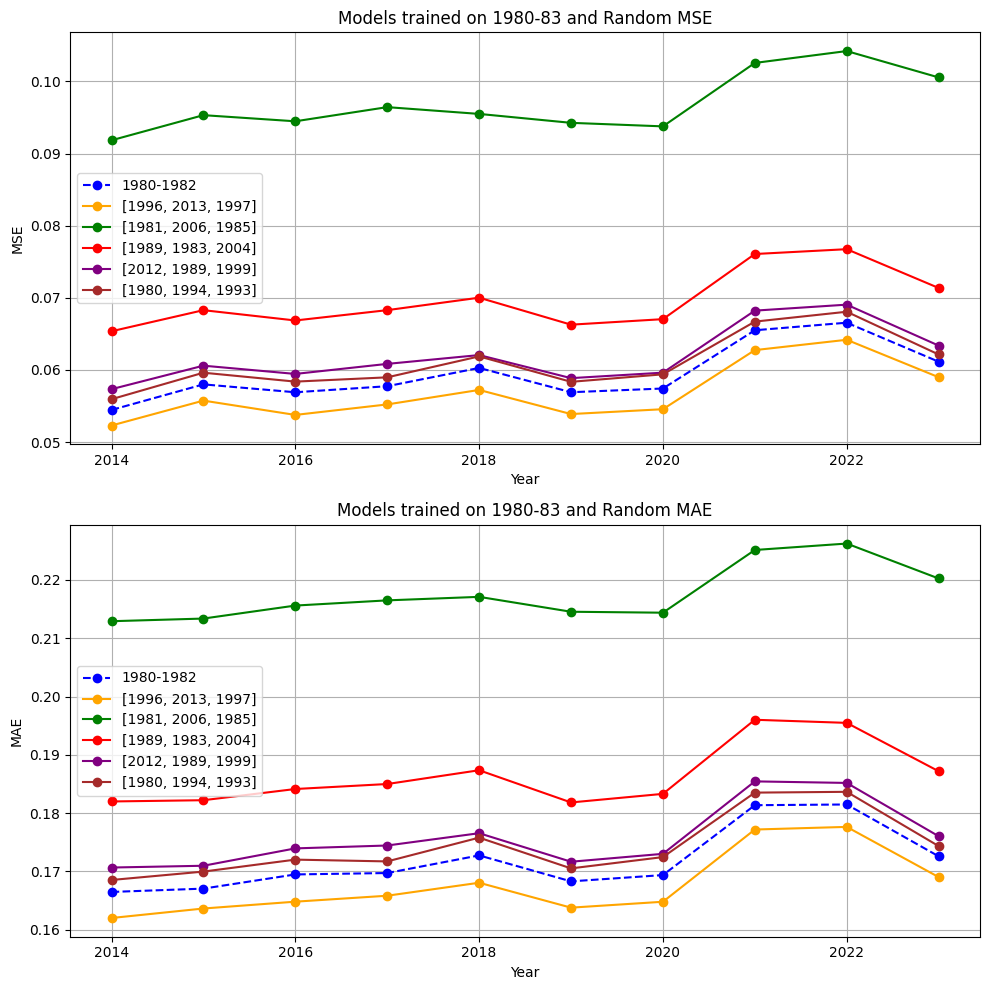

In [12]:
def plot_metrics_over_year_rand(years, mses, maes):
    n_models = len(mses)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

    
    for i, model in enumerate(['EDSR_80', 'EDSR_Random', 'EDSR_Random_1', 'EDSR_Random_2', 'EDSR_Random_3', 'EDSR_Random_4']):
        if model == 'EDSR_80':
            #dashed line
            ax[0].plot(years, mses[model], 'o--', label=rand_labels[i], color=colors[i])
            ax[1].plot(years, maes[model], 'o--', label=rand_labels[i], color=colors[i])
        else:
            ax[0].plot(years, mses[model], 'o-', label=rand_labels[i], color=colors[i])
            ax[1].plot(years, maes[model], 'o-', label=rand_labels[i], color=colors[i])

        ax[0].set_title(f'Models trained on 1980-83 and Random MSE')
        ax[0].set_xlabel('Year')
        ax[0].set_ylabel('MSE')
        ax[0].legend()
        ax[0].grid(True)

        ax[1].set_title(f'Models trained on 1980-83 and Random MAE')
        ax[1].set_xlabel('Year')
        ax[1].set_ylabel('MAE')
        ax[1].legend()
        ax[1].grid(True)

    plt.tight_layout()
    plt.show()
plot_metrics_over_year_rand(years, mses, maes)

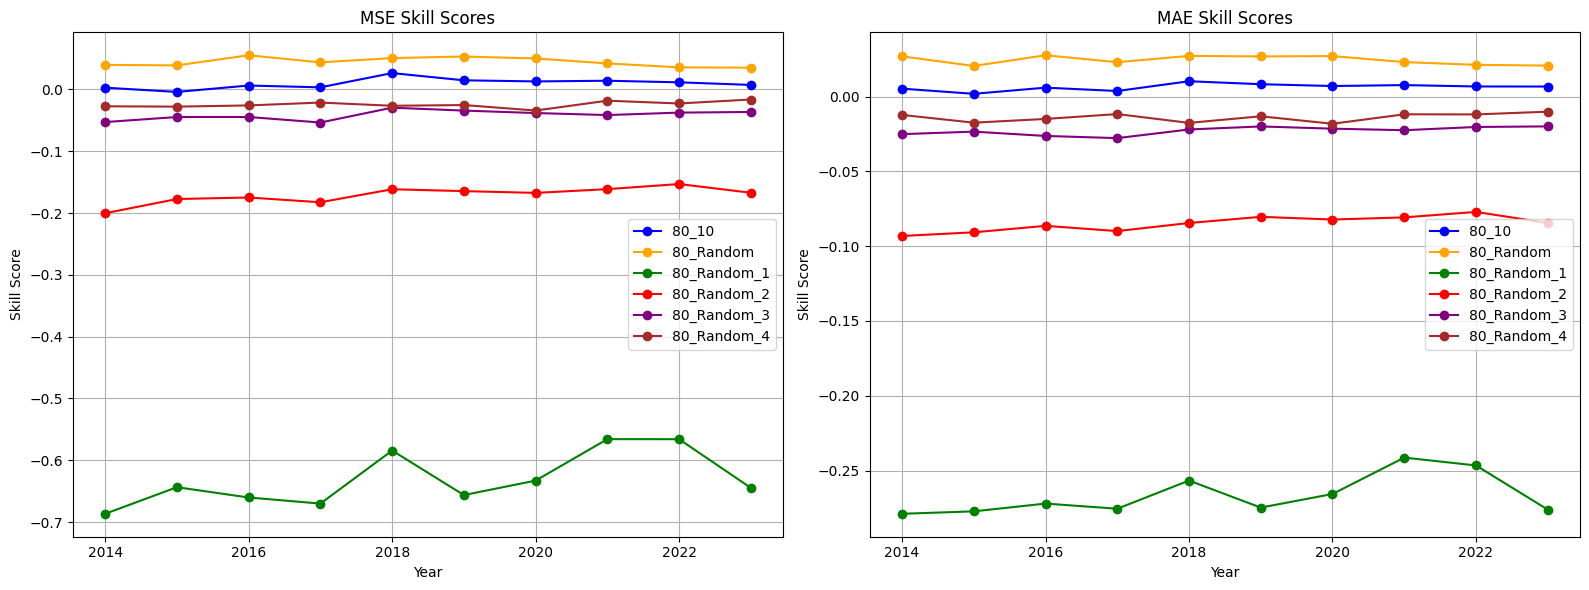

In [13]:
def plot_skill_scores(years, mse_skill_scores, mae_skill_scores):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
    for i, score in enumerate(mse_skill_scores):
        ax[0].plot(years, mse_skill_scores[score], 'o-', label=f"{score}", color=colors[i])
        ax[0].set_title('MSE Skill Scores')
        ax[0].set_xlabel('Year')
        ax[0].set_ylabel('Skill Score')
        ax[0].legend()
        ax[0].grid(True)

        ax[1].plot(years, mae_skill_scores[score], 'o-', label=f"{score}", color=colors[i])
        ax[1].set_title('MAE Skill Scores')
        ax[1].set_xlabel('Year')
        ax[1].set_ylabel('Skill Score')
        ax[1].legend()
        ax[1].grid(True)

    plt.tight_layout()
    plt.show()
    
plot_skill_scores(years, mse_skill_scores, mae_skill_scores)

[2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [33]:
# evaluate model trained on 2020-2022 on data from 1980-2019

train_start_reverse = '2020-01-01'
train_end_reverse = '2022-12-31'
preds_dir_reverse = '../../preds/'

eval_split_2020, gt_2020, scale_2020 = get_ground_truth_ws(data_dir=dataset_dir,
                                                            train_start=train_start_reverse,
                                                            train_end=train_end_reverse,
                                                            test_year=2023)
lr_wind_speeds_2020 = get_low_res_ws(eval_split_2020, SCALING_FACTOR)

def get_ws_fields_20_23(files_dir, scaling_factor, year, norm_scales, gt_ws):
    files = os.listdir(files_dir)
    ws_fields = [gt_ws]
    names = [ "HR Ground Truth"]
    norm_scale_1 = norm_scales[0]
    norm_scale_2 = norm_scales[1]
    
    for file in files:
        if not file.endswith(f'{scaling_factor}x.pt'):
            continue
               
        if file == f'EDSR_20_23_{year}_{scaling_factor}x.pt':
            field = torch.load(files_dir + file, weights_only=False)
            edsr_2023 = get_original_wind_speed(field, norm_scale_1)
            names.append("EDSR 20_22")
            ws_fields.append(edsr_2023)
        
        if file == f'EDSR_ws_temp_{year}_{scaling_factor}x.pt':
            field = torch.load(files_dir + file, weights_only=False)
            edsr_80 = get_original_wind_speed(field, norm_scale_2)
            names.append("EDSR 80_82")
            ws_fields.append(edsr_80)
            
    return ws_fields, names

ws_dict_20 = {year: {} for year in range(1980, 2020)}
for year in range(1980, 2020):
    # print(year)
    # case: train year start is after test year, load dataset always from oldest date to newest date
    

    eval_split, ground_truth_wind_speeds, scale1 = get_ground_truth_ws(data_dir=dataset_dir,
                                                                    train_start=train_start_reverse,
                                                                    train_end=train_end_reverse,
                                                                    test_year=year)
    _, _, scale2 = get_ground_truth_ws(data_dir=dataset_dir,
                                        train_start=TRAIN_START_1,
                                        train_end=TRAIN_END_1,
                                        test_year=year)
    ws_fields, names = get_ws_fields_20_23(files_dir=preds_dir_reverse, 
                                        scaling_factor=SCALING_FACTOR, 
                                        year=year, 
                                        norm_scales = [scale1, scale2],
                                       
                                        gt_ws=ground_truth_wind_speeds)
    
    edsr_20_22 = ws_fields[names.index('EDSR 20_22')]
    ws_dict_20[year]['EDSR_20_22'] = edsr_20_22
    # 1908 ws fields start only from 1984
    if year >= 1984:
        edsr_80_82 = ws_fields[names.index('EDSR 80_82')]
        ws_dict_20[year]['EDSR_80_82'] = edsr_80_82
    ws_dict_20[year]['Ground Truth'] = ground_truth_wind_speeds


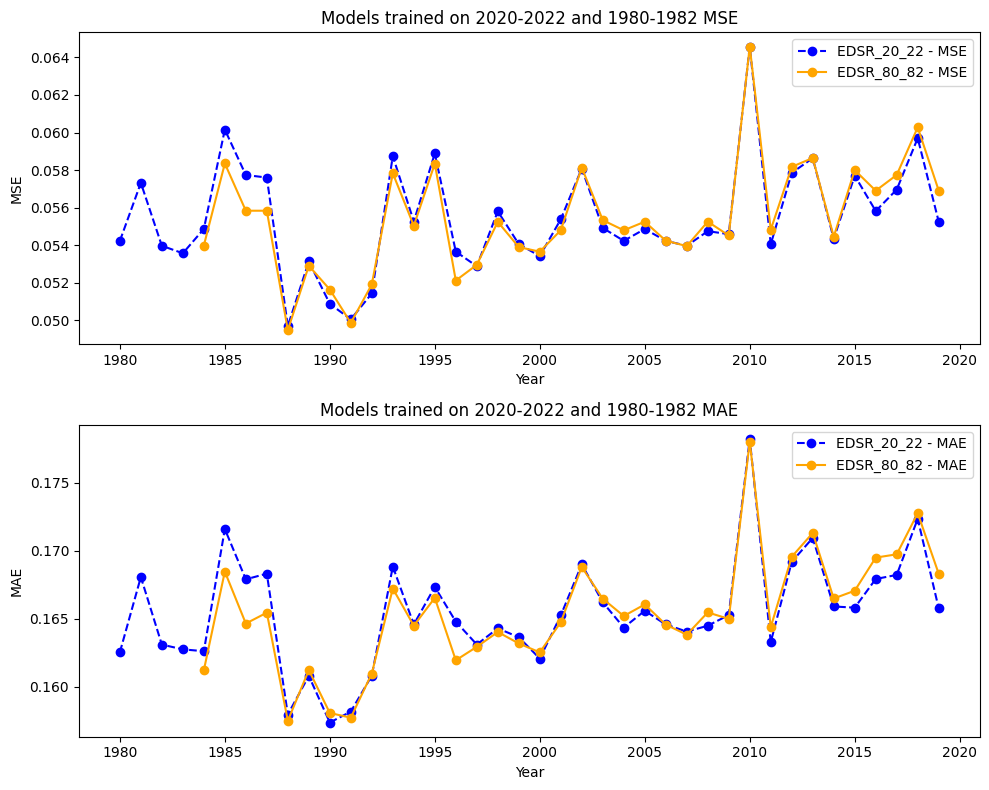

In [36]:
def get_metrics_over_time_20_22(years):
    mses = {'EDSR_20_22': [], 'EDSR_80_82': []}
    maes = {'EDSR_20_22': [], 'EDSR_80_82': []}
    
    for year in years:
        ground_truth_wind_speeds = ws_dict_20[year]['Ground Truth']
        mse_edsr, mae_edsr = get_metrics(ws_dict_20[year]['EDSR_20_22'], ground_truth_wind_speeds)
        mses['EDSR_20_22'].append(mse_edsr)
        maes['EDSR_20_22'].append(mae_edsr)
        
        if year >= 1984:
            mse_80_82, mae_80_82 = get_metrics(ws_dict_20[year]['EDSR_80_82'], ground_truth_wind_speeds)
            mses['EDSR_80_82'].append(mse_80_82)
            maes['EDSR_80_82'].append(mae_80_82)
    return mses, maes

mses_20_22, maes_20_22 = get_metrics_over_time_20_22(range(1980, 2020))


# plot mses and maes for model trained on 2020-2022 and compare to model trained on 1980-1982, data for the second model is available from 1984

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
colors = ['blue', 'orange']
for i, model in enumerate(['EDSR_20_22', 'EDSR_80_82']):
    if model == 'EDSR_20_22':
        ax[0].plot(range(1980, 2020), mses_20_22[model], 'o--', label=f"{model} - MSE", color=colors[i])
        ax[1].plot(range(1980, 2020), maes_20_22[model], 'o--', label=f"{model} - MAE", color=colors[i])
    else:
        ax[0].plot(range(1984, 2020), mses_20_22[model], 'o-', label=f"{model} - MSE", color=colors[i])
        ax[1].plot(range(1984, 2020), maes_20_22[model], 'o-', label=f"{model} - MAE", color=colors[i])
    
ax[0].set_title(f'Models trained on 2020-2022 and 1980-1982 MSE')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('MSE')
ax[0].legend()

ax[1].set_title(f'Models trained on 2020-2022 and 1980-1982 MAE')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('MAE')
ax[1].legend()

plt.tight_layout()
plt.show()

